## 비교군 : DBSCAN

### 라이브러리 호출

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### 한글 폰트 설정

In [5]:
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

### Step1 : 데이터 준비 및 전처리

In [7]:
# 2. 데이터 불러오기
df = pd.read_csv('single variable_data.csv')

# K-Means와 동일한 조건 비교를 위해 후진제거법 최종 9개 핵심 변수의 _std 버전만 선택
surviving_cols = [
    'risk_depression', 'risk_iadl', 'risk_nutrition', 'risk_suicide', 'risk_smoke',
    'risk_meet', 'risk_network', 'risk_subj_econ', 'risk_housing_tenure'
]
surviving_cols_std = [col + '_std' for col in surviving_cols]

In [8]:
# 학습 데이터셋 구성
X_scaled = df[surviving_cols_std]

In [9]:
# 4. PCA 적용 (차원을 8개로 압축 - 기존 로직 유지)
pca = PCA(n_components=8, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"DBSCAN용 데이터 준비 완료 (K-Means와 동일 조건): {X_pca.shape}")

DBSCAN용 데이터 준비 완료 (K-Means와 동일 조건): (3448, 8)


### Step2 : 최적의 반경(eps) 찾기: K-Distance Graph

In [11]:
# K-Distance Graph 그리기 (min_samples는 보통 차원의 2배인 16으로 설정)
min_samples_val = 16 
neighbors = NearestNeighbors(n_neighbors=min_samples_val)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

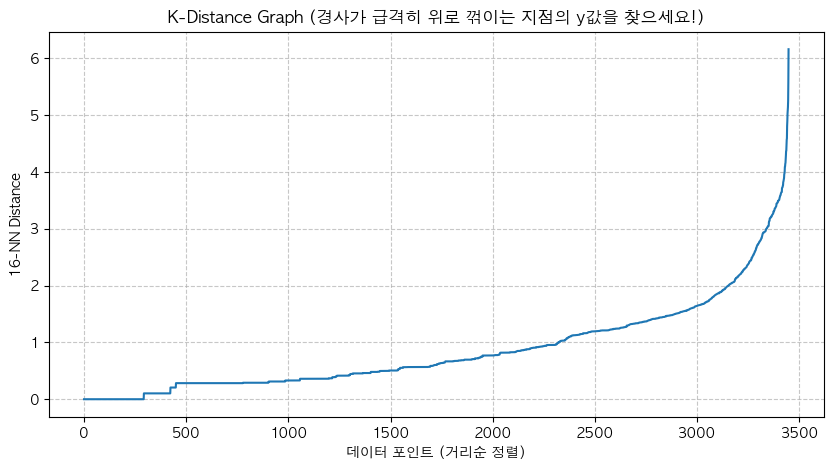

In [12]:
# 가장 먼 이웃(16번째)과의 거리를 기준으로 오름차순 정렬
distances = np.sort(distances[:, -1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-Distance Graph (경사가 급격히 위로 꺾이는 지점의 y값을 찾으세요!)')
plt.xlabel('데이터 포인트 (거리순 정렬)')
plt.ylabel(f'{min_samples_val}-NN Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [13]:
eps_val = 2.5

### Step 3 : DBSCAN 군집화 실행 (eps={eps_val}, min_samples={min_samples_val})

In [14]:
# DBSCAN 모델 학습
dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
df['dbscan_cluster'] = dbscan.fit_predict(X_pca)

In [15]:
# 결과 출력 및 실루엣 스코어 계산
print("\n[군집별 데이터 개수 (-1은 노이즈/이상치)]")
print(df['dbscan_cluster'].value_counts().sort_index())

n_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
if n_clusters > 1:
    mask = df['dbscan_cluster'] != -1
    score = silhouette_score(X_pca[mask], df['dbscan_cluster'][mask])
    print(f"\n노이즈를 제외한 핵심 군집들의 실루엣 점수: {score:.4f}")
else:
    print("\n경고: 정상 군집이 1개 이하로 형성되었습니다. eps 값을 조금 더 늘리거나 줄여보세요.")


[군집별 데이터 개수 (-1은 노이즈/이상치)]
dbscan_cluster
-1      82
 0    2754
 1     394
 2     166
 3      23
 4      29
Name: count, dtype: int64

노이즈를 제외한 핵심 군집들의 실루엣 점수: 0.3416


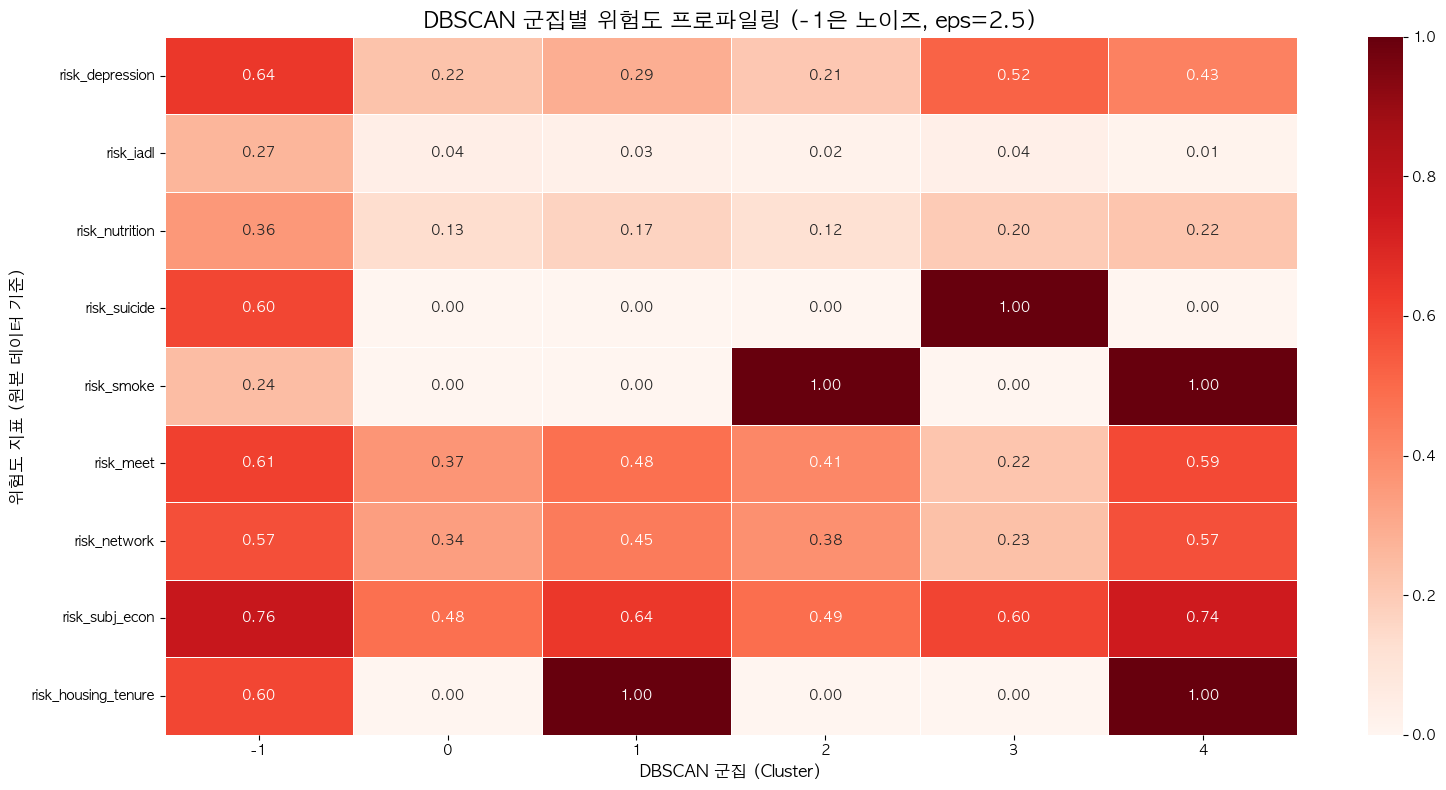

In [19]:
# 군집 프로파일링 히트맵 (원본 데이터 기준 평균값 출력)
dbscan_profile = df.groupby('dbscan_cluster')[surviving_cols].mean()

plt.figure(figsize=(16, 8))
sns.heatmap(dbscan_profile.T, cmap='Reds', annot=True, fmt=".2f", linewidths=.5)
plt.title(f'DBSCAN 군집별 위험도 프로파일링 (-1은 노이즈, eps={eps_val})', fontsize=16)
plt.xlabel('DBSCAN 군집 (Cluster)', fontsize=12)
plt.ylabel('위험도 지표 (원본 데이터 기준)', fontsize=12)
plt.tight_layout()
plt.show()